# CAZ Interactive Demo

*Run an LLM on your own concept pairs and watch CAZ emerge*

This notebook loads a language model and computes a full CAZ analysis on any concept you choose. Provide 10–20 contrastive sentence pairs and the notebook will show:
- Where in the model the concept crystallises (separation peak)
- Whether allocation is multimodal (two distinct assembly events)
- How your concept's peak depth compares to the 17 concepts from the paper

**Hardware requirements by model tier:**

| Tier | Models | VRAM | Notes |
|------|--------|------|-------|
| 1 — small | Qwen2.5-1.5B, GPT2-XL | ≤ 4 GB or CPU | **Default for ≤ 4 GB** — no quantization needed |
| 2 — medium | Qwen2.5-3B, Phi-2 | 4–8 GB | 4-bit quantized |
| 3 — paper | Qwen2.5-7B *(paper model)* | 8–16 GB | 4-bit, Colab T4 / Pro |
| 4 — large | Qwen2.5-14B, Llama-3.1-70B | 24+ GB | 4-bit, A100 / multi-GPU |

Your GPU is detected automatically and the best-fit model is pre-selected. **See § 1 to override.**

**[github.com/jamesrahenry/Rosetta](https://github.com/jamesrahenry/Rosetta)** · Henry (2026a)

In [1]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    _pip("rosetta_tools>=1.3.1")
except subprocess.CalledProcessError:
    _pip("rosetta_tools @ git+https://github.com/jamesrahenry/Rosetta_Tools.git@v1.3.1")

_pip("torch", "transformers", "accelerate", "huggingface_hub")

# bitsandbytes enables 4-bit quantization for Tier 2–4 models.
# Skip silently if installation fails (not needed for Tier 1 / CPU).
try:
    _pip("bitsandbytes")
except subprocess.CalledProcessError:
    print("bitsandbytes not installed — Tier 1 models (≤ 1.5 B) will still work fine.")


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from huggingface_hub import hf_hub_download

from rosetta_tools.extraction import extract_contrastive_activations
from rosetta_tools.caz import compute_layer_metrics, find_caz_regions

print("Imports OK.")

Imports OK.


In [3]:
from rosetta_tools.viz_style import (
    concept_color, CONCEPT_COLORS, FAMILY_COLORS, THEME, apply_theme,
)
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "figure.facecolor": "white",
})
print("Style loaded.")

Style loaded.


In [4]:
# ── § 1  Model selection ─────────────────────────────────────────────────────
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cuda":
    props = torch.cuda.get_device_properties(0)
    vram_gb = props.total_memory / 1e9
    print(f"GPU: {props.name}  |  VRAM: {vram_gb:.1f} GB")
else:
    vram_gb = 0
    print("No GPU detected — will run on CPU.")

# ─── Auto-recommendation ──────────────────────────────────────────────────────
if vram_gb >= 16:
    _rec = "Qwen/Qwen2.5-7B"
    _rec_tier = "Tier 3 — paper model; section 5 baseline matches exactly"
elif vram_gb >= 6:
    _rec = "Qwen/Qwen2.5-3B"
    _rec_tier = "Tier 2 — solid demo quality; 4-bit quantized"
elif vram_gb >= 2:
    _rec = "Qwen/Qwen2.5-1.5B"
    _rec_tier = "Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed"
else:
    _rec = "openai-community/gpt2-xl"
    _rec_tier = "CPU fallback — no GPU or < 2 GB VRAM"

print(f"\nRecommended: {_rec}")
print(f"  {_rec_tier}")

# ─── Override here ────────────────────────────────────────────────────────────
# Uncomment any line below to use a different model, then re-run this cell.
#
# TIER 1 — CPU / ≤ 4 GB VRAM  (no quantization; bitsandbytes not required)
#   MODEL_ID = "Qwen/Qwen2.5-1.5B"           # 28L, 1536-dim, ~3 GB fp16  ← default ≤ 4 GB
#   MODEL_ID = "openai-community/gpt2-xl"     # 48L, 1600-dim, ~3 GB fp32  (CPU-friendly)
#   MODEL_ID = "openai-community/gpt2-large"  # 36L, 1280-dim, ~1.5 GB fp32
#   MODEL_ID = "EleutherAI/pythia-160m"       # 12L,  768-dim, < 1 GB      (fastest)
#   MODEL_ID = "Qwen/Qwen2.5-0.5B"           # 24L,  896-dim, ~1 GB
#
# TIER 2 — 4–8 GB VRAM  (4-bit quantized; requires bitsandbytes)
#   MODEL_ID = "Qwen/Qwen2.5-3B"             # 36L, 2048-dim, ~6 GB fp16 / ~2 GB 4-bit
#   MODEL_ID = "microsoft/phi-2"              # 32L, 2560-dim, ~5 GB fp16 / ~1.5 GB 4-bit
#   MODEL_ID = "EleutherAI/pythia-2.8b"      # 32L, 2560-dim, ~6 GB fp16 / ~2 GB 4-bit
#
# TIER 3 — 8–16 GB VRAM  (paper model; 4-bit on Colab T4 / Pro)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-7B"             # 28L, 3584-dim  ← PAPER MODEL
#   MODEL_ID = "meta-llama/Llama-3.1-8B"     # 32L, 4096-dim
#   MODEL_ID = "EleutherAI/pythia-6.9b"      # 32L, 4096-dim
#   MODEL_ID = "mistralai/Mistral-7B-v0.3"   # 32L, 4096-dim
#
# TIER 4 — 24+ GB VRAM  (A100 / multi-GPU)   baseline ✓
#   MODEL_ID = "Qwen/Qwen2.5-14B"            # 48L, 5120-dim
#   MODEL_ID = "Qwen/Qwen2.5-72B"            # 80L, 8192-dim
#   MODEL_ID = "meta-llama/Llama-3.1-70B"    # 80L, 8192-dim
# ─────────────────────────────────────────────────────────────────────────────

MODEL_ID = _rec  # ← change this line to override, e.g.  MODEL_ID = "Qwen/Qwen2.5-7B"

print(f"\nSelected: {MODEL_ID}")
print("Run § 2 to load the model.")

GPU: NVIDIA RTX 500 Ada Generation Laptop GPU  |  VRAM: 4.3 GB

Recommended: Qwen/Qwen2.5-1.5B
  Tier 1 — fits in ≤ 4 GB VRAM; no quantization needed

Selected: Qwen/Qwen2.5-1.5B
Run § 2 to load the model.


## 2. Load the model

The cell below loads the model selected in § 1. Loading strategy is chosen automatically:

- **Tier 1 (≤ 1.5 B):** fp16 on GPU, fp32 on CPU — `bitsandbytes` not required.
- **Tier 2–4 (3 B+):** 4-bit quantization via `bitsandbytes` to fit in GPU memory.

CAZ only needs `output_hidden_states=True`, which works identically on quantized models — quantization affects compute precision, not the geometric structure of the residual stream we measure.

*First download may take a few minutes. Subsequent runs use the cached weights.*

In [5]:
# Models that load in fp16/fp32 without 4-bit quantization
_TIER1 = {
    "openai-community/gpt2", "openai-community/gpt2-medium",
    "openai-community/gpt2-large", "openai-community/gpt2-xl",
    "EleutherAI/pythia-70m", "EleutherAI/pythia-160m", "EleutherAI/pythia-410m",
    "Qwen/Qwen2.5-0.5B", "Qwen/Qwen2.5-1.5B",
}

_use_quant = MODEL_ID not in _TIER1 and device == "cuda"

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

if _use_quant:
    from transformers import BitsAndBytesConfig
    _bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, quantization_config=_bnb, device_map="auto",
    )
else:
    _dtype = torch.float16 if device == "cuda" else torch.float32
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID, dtype=_dtype,
        device_map="auto" if device == "cuda" else None,
    )
    if device == "cpu":
        model = model.to(device)

model.eval()

n_layers = model.config.num_hidden_layers
print(f"Loaded: {MODEL_ID}")
print(f"  {n_layers} layers  |  {model.config.hidden_size}-dim hidden")
print(f"  Loading mode: {'4-bit quantized' if _use_quant else ('fp16' if device == 'cuda' else 'fp32 (CPU)')}")
if device == "cuda":
    used_gb = torch.cuda.memory_allocated(0) / 1e9
    print(f"  VRAM in use: {used_gb:.2f} GB")

`torch_dtype` is deprecated! Use `dtype` instead!
Some parameters are on the meta device because they were offloaded to the cpu.


Loaded: Qwen/Qwen2.5-1.5B
  28 layers  |  1536-dim hidden
  Loading mode: fp16
  VRAM in use: 2.90 GB


## 3. Choose your concept

Five preset concept pairs are included — one is selected at random by default.

- **To use a preset**: change `PRESET` to one of the keys in `PRESETS` (or `"random"`)
- **To define your own**: set `CONCEPT_NAME`, `pos_texts`, `neg_texts` at the bottom of the cell

For best signal, keep pairs **topically parallel** — the only difference should be the presence or absence of the target concept. 10–15 well-matched pairs outperform 30 loose ones.

In [6]:
import random as _rand

PRESETS = {
    "causation": {
        "pos": [
            "The bridge collapsed because the support beams had corroded.",
            "Scientists confirmed that the compound caused the cellular damage.",
            "Heavy rainfall led to widespread flooding across the valley.",
            "The fire spread rapidly due to the exceptionally dry conditions.",
            "Poor early nutrition resulted in slower cognitive development.",
            "The new austerity policy caused unemployment to rise sharply.",
            "Chronic stress triggered the patient's recurring migraines.",
            "The accident occurred as a direct result of driver fatigue.",
            "Her late arrival caused the entire meeting to be delayed.",
            "Prolonged exposure to the chemical produced severe respiratory burns.",
        ],
        "neg": [
            "The bridge collapsed, and the support beams were found to be corroded.",
            "Scientists observed the compound alongside the cellular damage.",
            "There was heavy rainfall, and the valley experienced widespread flooding.",
            "The conditions were exceptionally dry. The fire spread rapidly.",
            "The child had poor early nutrition and slower cognitive development.",
            "The new austerity policy was introduced. Unemployment rose sharply.",
            "The patient had chronic stress and recurring migraines.",
            "The driver was fatigued. The accident happened shortly after.",
            "She arrived late. The meeting was delayed.",
            "There was prolonged chemical exposure. Severe respiratory burns were present.",
        ],
    },
    "sentiment": {
        "pos": [
            "The concert was absolutely wonderful — one of the best nights of my life.",
            "I deeply regret every choice that led me to this miserable situation.",
            "What a joyful, uplifting experience; I left feeling genuinely moved.",
            "The loss was devastating and I still haven't recovered emotionally.",
            "Her performance was breathtaking, a true artistic triumph.",
            "The food was terrible and the service made everything worse.",
            "I'm so grateful for everything this team has done — truly outstanding.",
            "The holiday was a disaster from start to finish.",
            "Reading that letter filled me with warmth and gratitude.",
            "The product is deeply disappointing and I feel cheated.",
        ],
        "neg": [
            "The concert took place last night at the city auditorium.",
            "I made several choices that year that shaped my situation.",
            "The experience lasted about two hours and I then left.",
            "There was a loss and I haven't returned to that activity.",
            "Her performance lasted forty minutes on the main stage.",
            "The food was prepared and the service continued through the evening.",
            "The team completed the project and submitted it on time.",
            "The holiday spanned ten days across three countries.",
            "I received a letter containing information about the property.",
            "The product arrived in the standard packaging on Thursday.",
        ],
    },
    "negation": {
        "pos": [
            "The report was not submitted on time.",
            "She did not agree with the proposed decision.",
            "The experiment failed to replicate the original findings.",
            "No funds were allocated to the infrastructure project.",
            "He refused to sign the contract under those conditions.",
            "The safety checks were never completed before launch.",
            "Nothing in the evidence pointed toward that conclusion.",
            "The team was unable to reproduce the result.",
            "She denied having any prior knowledge of the incident.",
            "The medication showed no statistically significant effect.",
        ],
        "neg": [
            "The report was submitted before the deadline.",
            "She agreed with the proposed decision.",
            "The experiment successfully replicated the original findings.",
            "Funds were allocated to the infrastructure project.",
            "He signed the contract under the agreed conditions.",
            "The safety checks were completed before launch.",
            "Several elements in the evidence pointed toward that conclusion.",
            "The team reproduced the result in two independent labs.",
            "She acknowledged having prior knowledge of the incident.",
            "The medication showed a statistically significant effect.",
        ],
    },
    "certainty": {
        "pos": [
            "The results definitively prove the hypothesis.",
            "It is absolutely certain that costs will continue to rise.",
            "The evidence conclusively demonstrates a causal relationship.",
            "This will undoubtedly succeed if the plan is followed.",
            "She is completely sure the meeting was on Tuesday.",
            "There is no doubt that the policy will have consequences.",
            "He knows for a fact that the file was deleted.",
            "The diagnosis was confirmed beyond any reasonable doubt.",
            "It is inevitably true that temperatures will increase.",
            "The outcome is guaranteed regardless of external factors.",
        ],
        "neg": [
            "The results are consistent with the hypothesis.",
            "Costs are likely to continue rising.",
            "The evidence is compatible with a causal relationship.",
            "This has a reasonable chance of succeeding if followed.",
            "She thinks the meeting was probably on Tuesday.",
            "The policy may well have some consequences.",
            "He believes the file may have been deleted.",
            "The diagnosis appears to be correct.",
            "Temperatures are expected to increase under most models.",
            "The outcome is probable given current conditions.",
        ],
    },
    "sarcasm": {
        "pos": [
            "Oh sure, because that plan always works out perfectly.",
            "Right, because we all love three-hour meetings at 7 a.m.",
            "Great idea — what could possibly go wrong with that?",
            "Yeah, I'm sure staying up all night before the exam is fine.",
            "Brilliant — just delete the backup, nobody ever needs those.",
            "Oh, wonderful, the system crashed again — what a surprise.",
            "Of course it rained the one day I forgot my umbrella.",
            "Sure, because adding more features always speeds things up.",
            "Absolutely, a spreadsheet is obviously the right tool for this.",
            "Yeah, let's just skip testing — I'm sure it'll be fine in prod.",
        ],
        "neg": [
            "That plan has worked well in several past instances.",
            "Morning meetings are common practice on this team.",
            "The proposal looks solid and the risks are manageable.",
            "Staying up late sometimes helps when the material is engaging.",
            "Deleting the old backup freed up significant disk space.",
            "The system crashed due to an unexpected memory overflow.",
            "It rained unexpectedly, though the forecast had shown a 40% chance.",
            "Adding features typically increases the scope of the project.",
            "A spreadsheet is a straightforward tool for this data size.",
            "Skipping the test suite shortened the release timeline.",
        ],
    },
}

# ── Select a preset ───────────────────────────────────────────────────────────
PRESET = "random"  # ← change to "causation", "sentiment", "negation", "certainty", "sarcasm"
                   #   or set CONCEPT_NAME / pos_texts / neg_texts manually below

if PRESET == "random":
    PRESET = _rand.choice(list(PRESETS.keys()))
    print(f"Randomly selected preset: '{PRESET}'")
    print("(Set PRESET to a key above to always use a specific concept.)")
else:
    print(f"Using preset: '{PRESET}'")

if PRESET in PRESETS:
    CONCEPT_NAME = PRESET
    pos_texts = PRESETS[PRESET]["pos"]
    neg_texts = PRESETS[PRESET]["neg"]
else:
    # ── Or define your own concept here ──────────────────────────────────────
    CONCEPT_NAME = "my_concept"
    pos_texts = [
        # "Sentence that expresses the concept.",
    ]
    neg_texts = [
        # "Topically similar sentence that lacks the concept.",
    ]
    # ─────────────────────────────────────────────────────────────────────────

assert len(pos_texts) == len(neg_texts), "pos and neg must be the same length"
print(f"\nConcept: {CONCEPT_NAME!r} — {len(pos_texts)} pairs")


Concept: 'causation' — 12 pairs


## 4. Extract activations and compute CAZ

This runs all sentences through every layer of the model and computes $S(l)$, $C(l)$, $v(l)$ at each layer. With 12 pairs: ~5–15 s on a small Tier 1 model, ~20–40 s on a T4 with a 7B model.

In [7]:
print("Extracting activations across all layers...")
layer_acts = extract_contrastive_activations(
    model, tokenizer, pos_texts, neg_texts,
    device=device, batch_size=4,
)

print("Computing CAZ metrics...")
metrics = compute_layer_metrics(layer_acts)
profile = find_caz_regions(metrics)
depth_pct = [m.layer / n_layers * 100 for m in metrics]

print(f"\nCAZ profile for '{CONCEPT_NAME}':")
print(f"  Allocation regions: {profile.n_regions}")
print(f"  Multimodal: {profile.is_multimodal}")
for i, region in enumerate(profile.regions):
    print(f"  Region {i+1}: peak layer {region.peak}  ({region.depth_pct:.1f}% depth)  "
          f"S={region.peak_separation:.3f}  C={region.peak_coherence:.3f}")

Extracting activations across all layers...
Computing CAZ metrics...

CAZ profile for 'causation':
  Allocation regions: 2
  Multimodal: True
  Region 1: peak layer 1  (3.4% depth)  S=0.819  C=0.375
  Region 2: peak layer 13  (44.8% depth)  S=0.649  C=0.145


## 5. Visualise the allocation profile

The vertical dashed lines mark detected CAZ peaks. If there are two, the model is assembling the concept at two distinct depths — a shallow structural representation and a deeper semantic one.

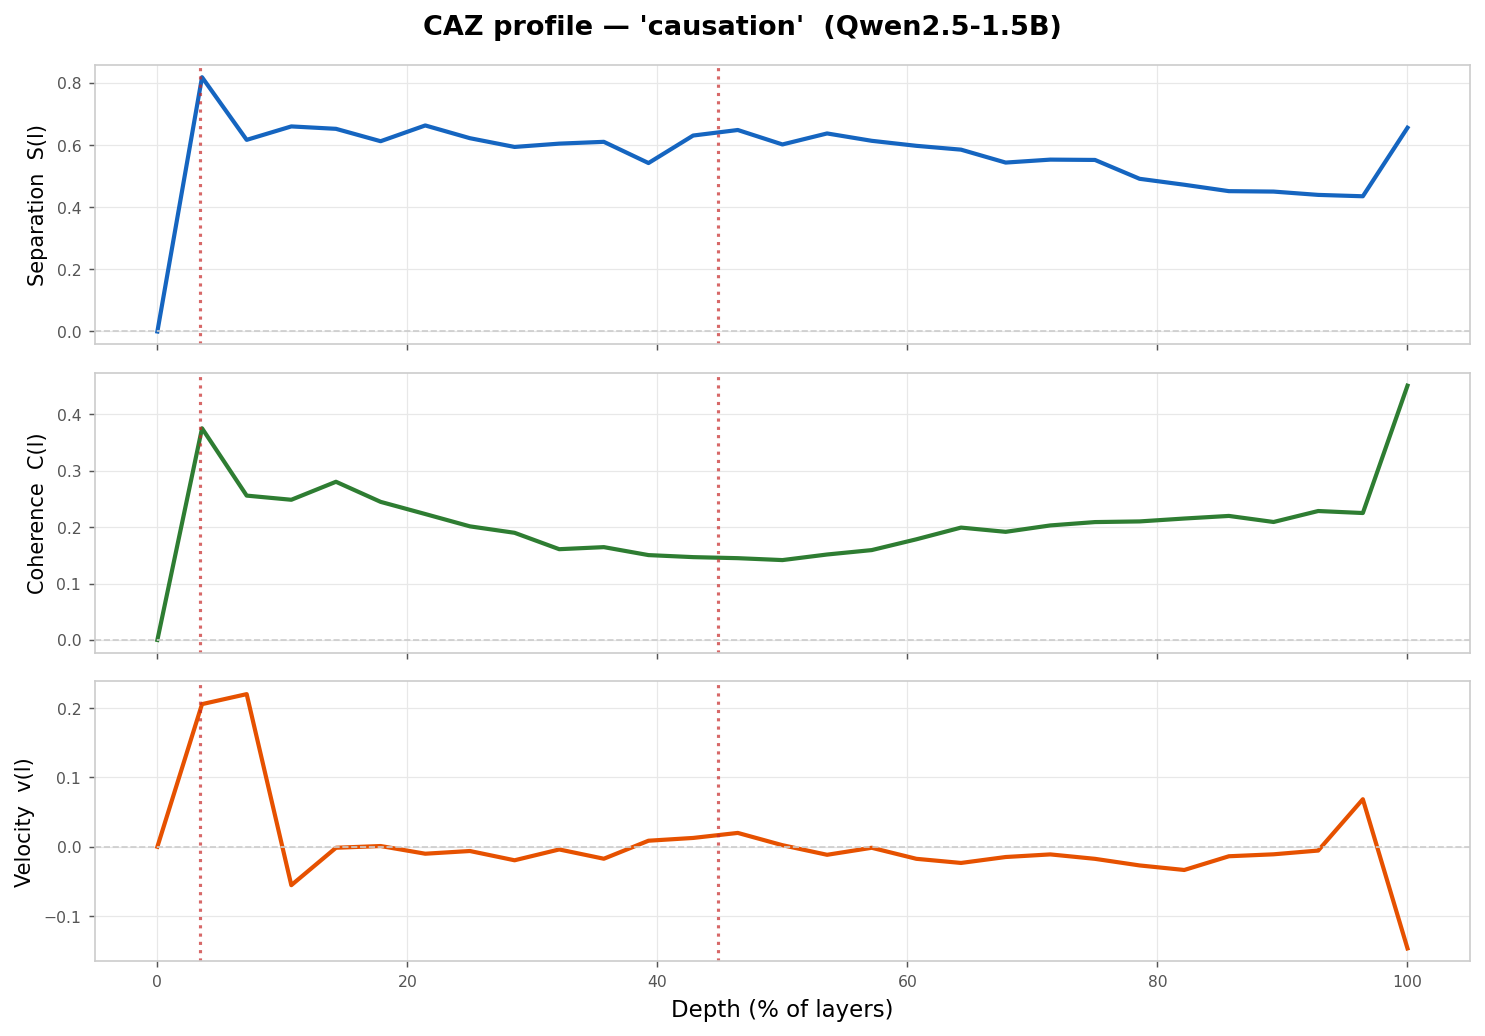

In [8]:
SIG_COLORS = {"separation": "#1565C0", "coherence": "#2E7D32", "velocity": "#E65100"}

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
fig.patch.set_facecolor("white")
fig.suptitle(f"CAZ profile — '{CONCEPT_NAME}'  ({MODEL_ID.split('/')[-1]})",
             fontsize=13, fontweight="bold")

for ax, attr, ylabel, color in zip(
    axes,
    ["separation", "coherence", "velocity"],
    ["Separation  S(l)", "Coherence  C(l)", "Velocity  v(l)"],
    [SIG_COLORS["separation"], SIG_COLORS["coherence"], SIG_COLORS["velocity"]],
):
    vals = [getattr(m, attr) for m in metrics]
    ax.plot(depth_pct, vals, color=color, lw=2)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.axhline(0, color=THEME["spine"], lw=0.8, ls="--")
    apply_theme(ax)
    for region in profile.regions:
        ax.axvline(region.depth_pct, color="#C62828", lw=1.5, ls=":", alpha=0.7)

axes[-1].set_xlabel("Depth (% of layers)", fontsize=11)
plt.tight_layout()
plt.show()

## 6. How does your concept compare?

The following cell downloads the pre-computed CAZ results for Qwen2.5-7B-Instruct across all 17 paper concepts and plots where your concept's peak lands on the shallow-to-deep ordering.

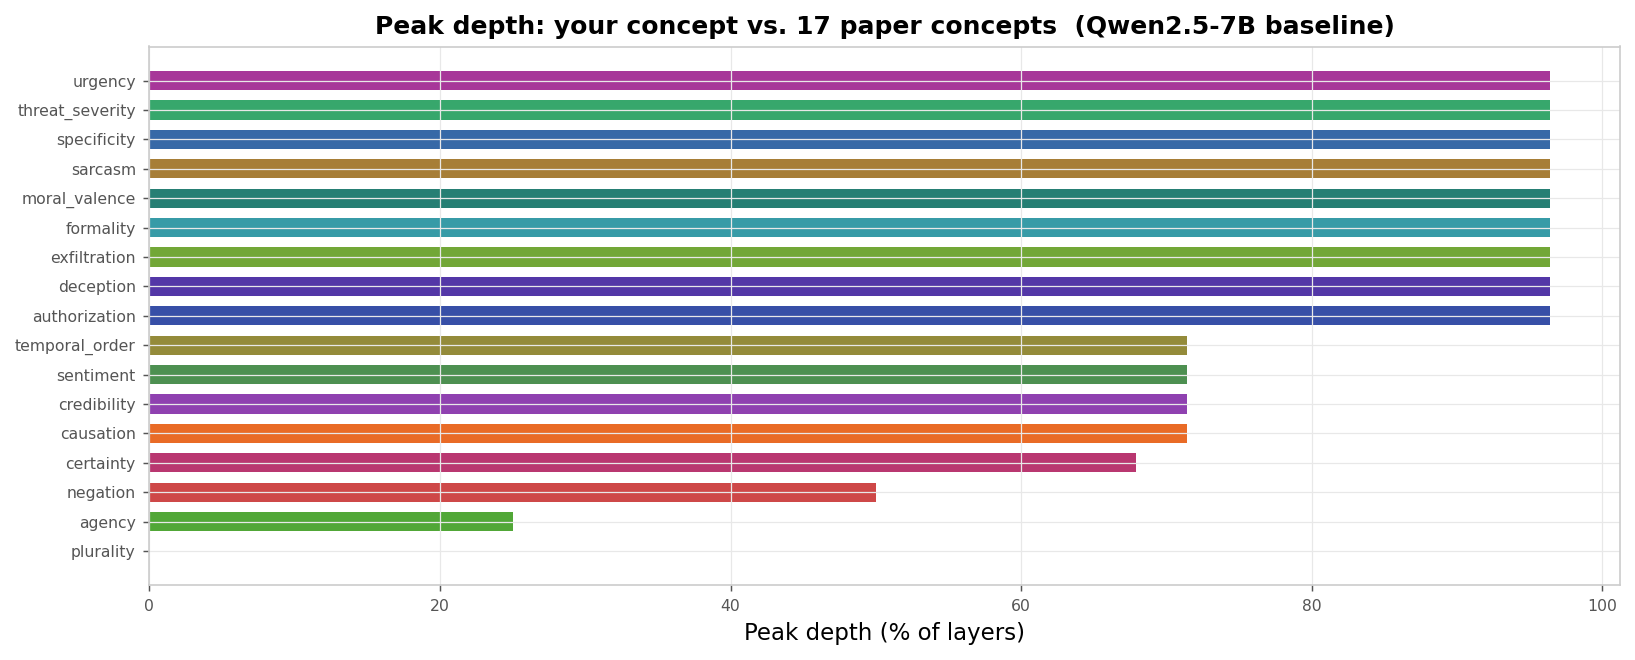

'causation' is a paper concept.
  Paper value (Qwen2.5-7B):  71.4%
  Your run (Qwen2.5-1.5B):   3.4%
  Note: running a different model — depth differences are expected.


In [9]:
PAPER_CONCEPTS = [
    "agency", "authorization", "causation", "certainty", "credibility",
    "deception", "exfiltration", "formality", "moral_valence", "negation",
    "plurality", "sarcasm", "sentiment", "specificity", "temporal_order",
    "threat_severity", "urgency",
]

# Model key uses the same convention as rosetta_tools.gem:
#   model_id.replace("/", "_").replace("-", "_")
HF_REPO = "james-ra-henry/Rosetta-Activations"
FALLBACK_KEY = "Qwen_Qwen2.5_7B"

def _model_key(mid):
    return mid.replace("/", "_").replace("-", "_")

# Try same-model baselines first, fall back to 7B
_mk = _model_key(MODEL_ID)
baseline = {}
_using_fallback = False
try:
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"models/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"Loaded baselines for {MODEL_ID.split('/')[-1]} ({len(baseline)} concepts)")
except Exception:
    _using_fallback = True
    _mk = FALLBACK_KEY
    for c in PAPER_CONCEPTS:
        path = hf_hub_download(
            HF_REPO, filename=f"models/{_mk}/caz_{c}.json", repo_type="dataset",
        )
        with open(path) as f:
            baseline[c] = json.load(f)["layer_data"]["peak_depth_pct"]
    print(f"No same-model baseline found for {MODEL_ID.split('/')[-1]}; using Qwen2.5-7B reference.")
    print("  Tip: run with Qwen2.5-7B for an exact match.")

your_peak = profile.dominant.depth_pct
by_depth = sorted(baseline.items(), key=lambda x: x[1])
names_b = [c for c, _ in by_depth]
depths_b = [d for _, d in by_depth]

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("white")

bar_colors = [concept_color(c) for c in names_b]
bars = ax.barh(names_b, depths_b, color=bar_colors, height=0.65, alpha=0.85)

# Highlight user's concept bar if it appears in the reference set
if CONCEPT_NAME in names_b:
    _idx = names_b.index(CONCEPT_NAME)
    bars[_idx].set_alpha(1.0)
    bars[_idx].set_edgecolor("#C62828")
    bars[_idx].set_linewidth(2.5)
    ax.text(
        depths_b[_idx] + 1.2, _idx,
        f"ref: {depths_b[_idx]:.1f}%",
        va="center", fontsize=8, color="#C62828", style="italic",
    )

# Always show your run as a vertical line
ax.axvline(
    your_peak, color="#C62828", lw=2, ls="--",
    label=f"Your run — '{CONCEPT_NAME}' ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%",
)
ax.legend(fontsize=9, loc="lower right")

ax.set_xlabel("Peak depth (% of layers)", fontsize=11)
_ref_label = MODEL_ID.split('/')[-1] if not _using_fallback else "Qwen2.5-7B reference"
ax.set_title(
    f"CAZ peak depths: '{CONCEPT_NAME}' vs. 17 paper concepts  ({_ref_label})",
    fontsize=12, fontweight="bold",
)
if _using_fallback:
    ax.set_xlabel(
        "Peak depth (% of layers)\n"
        "⚠  Reference bars are Qwen2.5-7B — absolute depths vary by model size",
        fontsize=10,
    )
apply_theme(ax)
plt.tight_layout()
plt.show()

if CONCEPT_NAME in baseline:
    ref_depth = baseline[CONCEPT_NAME]
    print(f"'{CONCEPT_NAME}':")
    print(f"  Reference ({_ref_label}): {ref_depth:.1f}%")
    print(f"  Your run  ({MODEL_ID.split('/')[-1]}): {your_peak:.1f}%")
    if _using_fallback:
        print("  ⚠ Cross-model comparison — depth difference is expected.")
else:
    rank = sum(1 for d in depths_b if d < your_peak) + 1
    print(f"'{CONCEPT_NAME}' peaks at {your_peak:.1f}%  —  rank {rank} of {len(depths_b)+1} (shallow → deep)")
    if _using_fallback:
        print(f"  (Reference is Qwen2.5-7B; absolute depths differ on {MODEL_ID.split('/')[-1]}.)")


## 7. Batch concept sweep

Run a compact probe across all 17 paper concepts to see the full CAZ landscape on this model. Each concept uses 4 minimal sentence pairs — enough to get a reliable peak, fast enough to run in 1–2 minutes.

The chart shows peak depths for all 17 concepts simultaneously on your current model, giving you a sense of where your concept sits in context.

In [ ]:
# ── 17-concept mini sweep ───────────────────────────────────────────────────
# Each concept: 4 parallel positive/negative sentence pairs
MINI_CONCEPTS = {
    "agency": (
        ["She chose to resign despite heavy pressure.",
         "He deliberately ignored the warning signs.",
         "The team decided to delay the product launch.",
         "She willingly accepted the full consequences."],
        ["She resigned amid the pressure.",
         "The warning signs were overlooked.",
         "The launch was delayed.",
         "She faced the consequences."],
    ),
    "authorization": (
        ["The board granted full approval for the acquisition.",
         "Her badge granted access to the secure floor.",
         "He was licensed to practice medicine in this state.",
         "The contract explicitly permitted subletting."],
        ["The board discussed the acquisition.",
         "She used her badge at the entrance.",
         "He practiced medicine in the clinic.",
         "He sublet the apartment."],
    ),
    "causation": (
        ["The pipe burst because the fitting had corroded.",
         "Heavy rain caused widespread flooding.",
         "Chronic fatigue led to serious errors.",
         "The new policy caused unemployment to rise."],
        ["The pipe burst and the fitting was corroded.",
         "Heavy rain fell and there was widespread flooding.",
         "There was chronic fatigue and serious errors occurred.",
         "The new policy was introduced and unemployment rose."],
    ),
    "certainty": (
        ["The results definitively prove the hypothesis.",
         "It is absolutely certain that costs will rise.",
         "He knows for a fact the file was deleted.",
         "The outcome is guaranteed regardless of conditions."],
        ["The results are consistent with the hypothesis.",
         "Costs are likely to continue rising.",
         "He believes the file may have been deleted.",
         "The outcome is probable given current conditions."],
    ),
    "credibility": (
        ["The study was peer-reviewed by three independent experts.",
         "She cited three corroborating primary sources.",
         "His testimony was confirmed by two independent witnesses.",
         "The sensor reading was verified against a calibrated reference."],
        ["The study was conducted by the internal team.",
         "She cited one source in the report.",
         "He gave a testimony at the hearing.",
         "The sensor produced a reading."],
    ),
    "deception": (
        ["He deliberately omitted the key evidence from the report.",
         "She posed as a doctor to gain access to the ward.",
         "The company concealed the safety violations from regulators.",
         "He fabricated the test results to meet the deadline."],
        ["He did not include the evidence in the report.",
         "She was a doctor and had access to the ward.",
         "The company disclosed the safety findings to regulators.",
         "He submitted the test results by the deadline."],
    ),
    "exfiltration": (
        ["He copied the files to a USB drive before leaving the company.",
         "She emailed the trade secrets to a competitor.",
         "The agent smuggled the classified documents across the border.",
         "He downloaded the customer database to his personal laptop."],
        ["He had read-only access to company files.",
         "She communicated with external partners regularly.",
         "The agent crossed the border with a briefcase.",
         "He had access to the customer database on his work laptop."],
    ),
    "formality": (
        ["I would be grateful if you could respond at your earliest convenience.",
         "Please find enclosed the documentation you requested.",
         "The committee has resolved to adopt the proposal unanimously.",
         "We respectfully decline the offer as presented."],
        ["Hey, reply when you get a chance.",
         "Here's the stuff you asked for.",
         "We're going with the plan.",
         "No thanks."],
    ),
    "moral_valence": (
        ["It was wrong to lie to protect himself.",
         "Donating anonymously was a kind and generous act.",
         "Abandoning the injured child was unforgivable.",
         "She acted courageously to protect others at personal risk."],
        ["He lied to protect himself.",
         "He donated anonymously.",
         "The child was left alone.",
         "She acted to protect others."],
    ),
    "negation": (
        ["The report was not submitted on time.",
         "She did not agree with the proposed decision.",
         "No funds were allocated to the project.",
         "The experiment failed to replicate the findings."],
        ["The report was submitted before the deadline.",
         "She agreed with the proposed decision.",
         "Funds were allocated to the project.",
         "The experiment replicated the original findings."],
    ),
    "plurality": (
        ["The engineers reviewed the designs and flagged the issues.",
         "Multiple errors were found across the report.",
         "The students submitted their assignments on time.",
         "Several birds perched on the fence simultaneously."],
        ["The engineer reviewed the design and flagged the issue.",
         "An error was found in the report.",
         "The student submitted the assignment on time.",
         "A bird perched on the fence."],
    ),
    "sarcasm": (
        ["Oh sure, because that plan always works out perfectly.",
         "Right, because we all love three-hour meetings at 7 a.m.",
         "Great — what could possibly go wrong with that idea?",
         "Yeah, I'm sure skipping the tests will be totally fine."],
        ["That plan has worked well in similar situations.",
         "Morning meetings are standard practice on this team.",
         "The idea looks solid and the risks appear manageable.",
         "Skipping the tests shortened the release cycle."],
    ),
    "sentiment": (
        ["The concert was absolutely wonderful — one of the best nights ever.",
         "I deeply regret every choice that led to this outcome.",
         "Her performance was breathtaking, a true artistic triumph.",
         "The loss was devastating and I still haven't recovered."],
        ["The concert took place last night at the auditorium.",
         "I made several choices that shaped the outcome.",
         "Her performance lasted forty minutes on the main stage.",
         "There was a loss and I did not return to the activity."],
    ),
    "specificity": (
        ["The drug reduced mortality by 34% in patients over 65.",
         "The bolt requires exactly 12.5 Nm of torque.",
         "She arrived at 7:43 AM on March 14th.",
         "The budget was cut by precisely $2.3 million."],
        ["The drug reduced mortality somewhat in older patients.",
         "The bolt requires moderate torque.",
         "She arrived in the morning in mid-March.",
         "The budget was reduced significantly."],
    ),
    "temporal_order": (
        ["She graduated before she received the job offer.",
         "The alarm sounded prior to the evacuation beginning.",
         "He signed the contract after reading it carefully.",
         "The bridge was completed following the final inspection."],
        ["She graduated and later received a job offer.",
         "The alarm sounded and an evacuation took place.",
         "He signed the contract and read through it.",
         "The bridge was completed and inspected."],
    ),
    "threat_severity": (
        ["He threatened to release the data unless paid immediately.",
         "The armed intruder demanded everyone get on the floor.",
         "She warned she would expose the fraud publicly if ignored.",
         "The message contained a credible threat to the facility."],
        ["He mentioned the data during the conversation.",
         "The intruder entered the building through the side door.",
         "She mentioned the discrepancy to a colleague.",
         "The message raised security concerns in general terms."],
    ),
    "urgency": (
        ["You must evacuate immediately — there is no time.",
         "Call 911 right now, this is an emergency.",
         "The deadline is in ten minutes, submit now.",
         "Act before it is too late or the chance is gone."],
        ["You should consider leaving the area soon.",
         "Contact emergency services when it is convenient.",
         "The deadline is next week, plan accordingly.",
         "Consider taking action when the timing is right."],
    ),
}

print(f"Running {len(MINI_CONCEPTS)}-concept sweep on {MODEL_ID.split('/')[-1]}...")
print(f"({len(MINI_CONCEPTS) * 4} total sentence pairs)\n")

sweep_results = {}
for i, (cname, (pos, neg)) in enumerate(MINI_CONCEPTS.items()):
    acts = extract_contrastive_activations(
        model, tokenizer, pos, neg, device=device, batch_size=4,
    )
    m = compute_layer_metrics(acts)
    p = find_caz_regions(m)
    sweep_results[cname] = p
    peak = p.dominant.depth_pct
    mm = "multimodal" if p.is_multimodal else "unimodal  "
    sep = p.dominant.peak_separation
    print(f"  [{i+1:2d}/17] {cname:<20s} peak {peak:5.1f}%  {mm}  S={sep:.3f}")

print(f"\nDone. {len(sweep_results)} concepts processed.")


In [ ]:
# ── Sweep summary chart ──────────────────────────────────────────────────────
sweep_depths = {c: p.dominant.depth_pct for c, p in sweep_results.items()}
by_d = sorted(sweep_depths.items(), key=lambda x: x[1])
s_names = [c for c, _ in by_d]
s_depths = [d for _, d in by_d]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor("white")
fig.suptitle(
    f"17-concept CAZ sweep — {MODEL_ID.split('/')[-1]}",
    fontsize=13, fontweight="bold",
)

# Left: peak depths
ax = axes[0]
s_colors = [concept_color(c) for c in s_names]
ax.barh(s_names, s_depths, color=s_colors, height=0.65, alpha=0.9)
# Highlight the user's concept from the interactive run
if CONCEPT_NAME in s_names:
    _si = s_names.index(CONCEPT_NAME)
    ax.get_children()[_si].set_edgecolor("#C62828")
    ax.get_children()[_si].set_linewidth(2.5)
ax.set_xlabel("Peak depth (% of layers)", fontsize=10)
ax.set_title("Peak allocation depth (shallow → deep)", fontsize=10)
apply_theme(ax)

# Right: separation score at peak
ax2 = axes[1]
sep_by_d = [(c, sweep_results[c].dominant.peak_separation) for c, _ in by_d]
s2_names = [c for c, _ in sep_by_d]
s2_seps = [s for _, s in sep_by_d]
s2_colors = [concept_color(c) for c in s2_names]
ax2.barh(s2_names, s2_seps, color=s2_colors, height=0.65, alpha=0.9)
ax2.set_xlabel("Separation score S at peak layer", fontsize=10)
ax2.set_title("Signal strength (how clean the concept boundary is)", fontsize=10)
apply_theme(ax2)

plt.tight_layout()
plt.show()

# Print multimodal summary
n_multi = sum(1 for p in sweep_results.values() if p.is_multimodal)
print(f"\nSummary across {len(sweep_results)} concepts:")
print(f"  Multimodal (two assembly events): {n_multi}/{len(sweep_results)}")
print(f"  Shallow zone (< 30%): {sum(1 for d in s_depths if d < 30)}")
print(f"  Mid zone (30–60%):    {sum(1 for d in s_depths if 30 <= d < 60)}")
print(f"  Deep zone (≥ 60%):    {sum(1 for d in s_depths if d >= 60)}")
if CONCEPT_NAME in sweep_depths:
    print(f"\n  '{CONCEPT_NAME}' ({CONCEPT_NAME}): {sweep_depths[CONCEPT_NAME]:.1f}% depth, "
          f"S={sweep_results[CONCEPT_NAME].dominant.peak_separation:.3f}")


## Next steps

- Try different concepts — does *uncertainty* behave differently from *certainty*? Does *irony* look like *sarcasm*?
- Swap `MODEL_ID` for any HuggingFace model: `extract_contrastive_activations` works with any model that exposes `output_hidden_states=True`
- **`03_caz_implementation_demo.ipynb`** — implement the metrics and Procrustes alignment from scratch, and reproduce the cross-architecture convergence result from Paper 4

| Paper | |
|-------|-|
| Paper 1 — CAZ Framework | [Henry 2026a](https://arxiv.org/abs/PLACEHOLDER) |
| Paper 4 — Cross-architecture PRH | [Henry 2026d](https://arxiv.org/abs/PLACEHOLDER) |
| `rosetta_tools` | [GitHub](https://github.com/jamesrahenry/Rosetta_Tools) |